# 3 — RESTORE: per-image marker positivity

Calls the cells positive for a marker, per donor.

- features are **Cytoplasm and Membrane** — disjoint regions. `Cell` is not used: it is a superset
  containing the membrane band, so it is collinear with it (r 0.84–0.96) and adds no information.
- a cell needs **both a nucleus and a cell body** to have a cytoplasm; cells without one are dropped.
- **every cell**, no subsampling.
- **no clipping** — the bright population is the signal.


## 1 — Load Cytoplasm and Membrane for every cell


In [2]:
f = glob.glob(str(COMPART/f'donor_id={DONOR}'/'*.parquet'))[0]
cy, mb = f'Cytoplasm__{MARKER}', f'Membrane__{MARKER}'
d = pd.read_parquet(f, columns=['object_id', cy, mb])
n_all = len(d)

# a cell needs both a nucleus and a cell body to have a cytoplasm
keep = np.isfinite(d[cy]) & np.isfinite(d[mb]) & (d[cy] >= 0) & (d[mb] >= 0)
d = d[keep].reset_index(drop=True)
C = d[cy].to_numpy(float)
M = d[mb].to_numpy(float)
print(f'{n_all:,} cells   ->  {len(d):,} with a cytoplasm   ({n_all-len(d):,} dropped)')
print(f'  Cytoplasm  median {np.median(C):8.1f}   max {C.max():9.1f}')
print(f'  Membrane   median {np.median(M):8.1f}   max {M.max():9.1f}')


1,781,276 cells   ->  1,621,163 with a cytoplasm   (160,113 dropped)
  Cytoplasm  median    654.5   max   44908.7
  Membrane   median    646.6   max   34961.4


## 2 — The two distributions


In [3]:
for nm, x in ((cy, C), (mb, M)):
    nz = x[x > 0]; lv = np.log10(nz)
    h, e = np.histogram(lv, bins=45, range=(lv.min(), lv.max()))
    print(f'--- {nm}   ({len(nz):,} nonzero)')
    for i in range(len(h)):
        print(f'{10**e[i]:9.1f} - {10**e[i+1]:9.1f} | {h[i]:9,} ' + '#'*int(50*h[i]/max(h.max(),1)))


--- Cytoplasm__CD11b   (1,621,156 nonzero)
      0.5 -       0.7 |         1 
      0.7 -       0.9 |         0 
      0.9 -       1.1 |         1 
      1.1 -       1.4 |         0 
      1.4 -       1.8 |         0 
      1.8 -       2.4 |         2 
      2.4 -       3.1 |         3 
      3.1 -       3.9 |         0 
      3.9 -       5.1 |         4 
      5.1 -       6.5 |         7 
      6.5 -       8.4 |         4 
      8.4 -      10.8 |         6 
     10.8 -      13.9 |        24 
     13.9 -      17.9 |        71 
     17.9 -      23.0 |       144 
     23.0 -      29.7 |       283 
     29.7 -      38.2 |       628 
     38.2 -      49.1 |     1,116 
     49.1 -      63.2 |     2,238 
     63.2 -      81.4 |     4,133 
     81.4 -     104.8 |     7,246 
    104.8 -     134.9 |    11,933 #
    134.9 -     173.7 |    17,576 #
    173.7 -     223.5 |    26,441 ##
    223.5 -     287.8 |    39,889 ####
    287.8 -     370.4 |    66,988 ######
    370.4 -     476.8 |   135,504

## 3 — Boundary in each compartment

Find the peak of the dim bulk, then walk right to the first local minimum in the smoothed density.
A cell is called positive when it is above the boundary in **both** compartments.


In [4]:
def find_boundary(values, bins=160, smooth=7):
    """Boundary between the dim bulk and the bright population, from this donor's own histogram."""
    p = values[values > 0]
    if p.size < 100: return np.nan, {}
    lp = np.log10(p)
    hh, ee = np.histogram(lp, bins=bins, range=(lp.min(), lp.max()))
    c = 0.5*(ee[:-1]+ee[1:])
    s = uniform_filter1d(hh.astype(float), size=smooth)
    mode = int(np.argmax(s))
    for i in range(mode+3, len(s)-3):
        if s[i] <= s[i-1] and s[i] <= s[i+1]:
            return 10**c[i], dict(mode=10**c[mode], centers=c, smooth=s)
    return np.nan, dict(mode=10**c[mode], centers=c, smooth=s)

tC, gC = find_boundary(C)
tM, gM = find_boundary(M)
is_pos = (C > tC) & (M > tM)
print(f'Cytoplasm  bulk peak {gC.get("mode", float("nan")):9.1f}   boundary {tC:9.1f}   above: {(C>tC).sum():,}')
print(f'Membrane   bulk peak {gM.get("mode", float("nan")):9.1f}   boundary {tM:9.1f}   above: {(M>tM).sum():,}')
print(f'\npositive in BOTH: {is_pos.sum():,}  ({is_pos.mean()*100:.4f}% of {len(d):,})')


Cytoplasm  bulk peak     656.4   boundary       nan   above: 0
Membrane   bulk peak     627.9   boundary       nan   above: 0

positive in BOTH: 0  (0.0000% of 1,621,163)


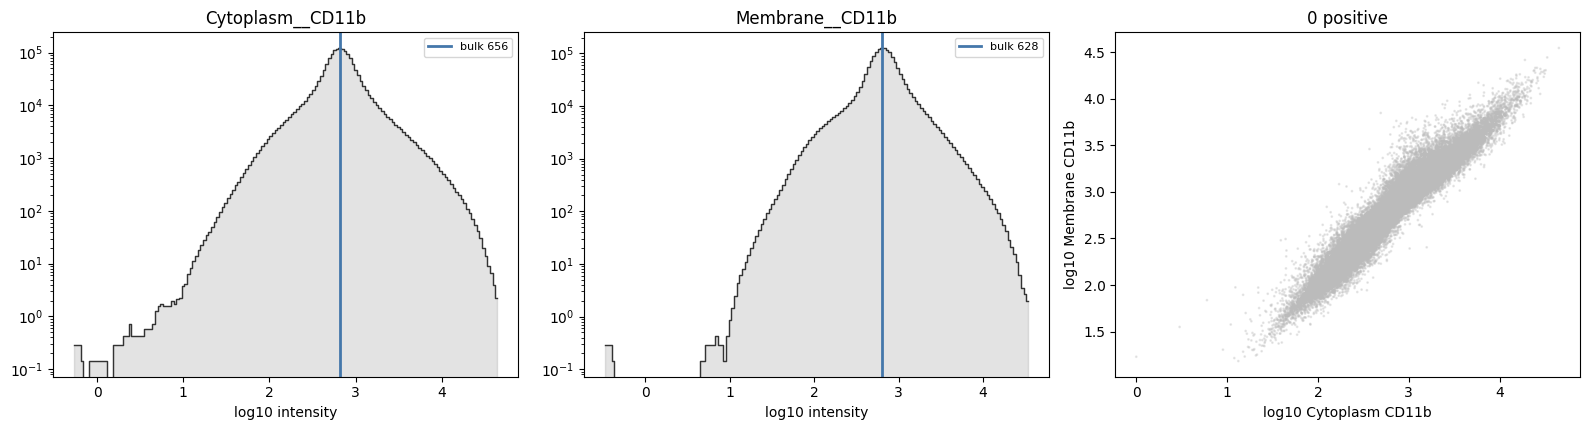

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16,4.4))
for a, (nm, x, t, g) in zip(ax, ((cy, C, tC, gC), (mb, M, tM, gM))):
    a.step(g['centers'], g['smooth'], where='mid', color='#333', lw=1)
    a.fill_between(g['centers'], g['smooth'], step='mid', alpha=.2, color='#777')
    a.axvline(np.log10(g['mode']), color='#4477AA', lw=2, label=f"bulk {g['mode']:.0f}")
    if np.isfinite(t): a.axvline(np.log10(t), color='#EE6677', lw=2, label=f'boundary {t:.0f}')
    a.set_yscale('log'); a.set_title(nm); a.set_xlabel('log10 intensity'); a.legend(fontsize=8)
s = np.random.default_rng(0).choice(len(C), min(200_000, len(C)), replace=False)  # plotting only
ax[2].scatter(np.log10(C[s]+1), np.log10(M[s]+1), s=1, c=np.where(is_pos[s], '#EE6677', '#BBBBBB'), alpha=.3)
if np.isfinite(tC): ax[2].axvline(np.log10(tC+1), color='#EE6677', lw=1)
if np.isfinite(tM): ax[2].axhline(np.log10(tM+1), color='#EE6677', lw=1)
ax[2].set_xlabel(f'log10 Cytoplasm {MARKER}'); ax[2].set_ylabel(f'log10 Membrane {MARKER}')
ax[2].set_title(f'{is_pos.sum():,} positive')
plt.tight_layout(); plt.show()


## 4 — Check the calls on the image

Import with `scripts/groovy/import_broad_lineage.groovy` — it matches on the QuPath detection UUID
(`object_id`) — and compare the called cells against the channel.


In [6]:
outdir = REPO/'data'/'positivity'/MARKER
outdir.mkdir(parents=True, exist_ok=True)
out = pd.DataFrame({'object_id': d['object_id'].astype(str),
                    'Cytoplasm': C, 'Membrane': M, f'{MARKER}_pos': is_pos})
dst = outdir/f'{MARKER}_{DONOR}.csv'
out.to_csv(dst, index=False)
print(f'{dst}\n{is_pos.sum():,} positive of {len(out):,}')
out[out[f'{MARKER}_pos']].head()


/home/smith6jt/IO60panc2nd/Islet-Explorer-Senior/data/positivity/CD11b/CD11b_6566.csv
0 positive of 1,621,163


,object_id,Cytoplasm,Membrane,CD11b_pos


## 5 — This marker across every donor


In [7]:
rows = []
for p in sorted(glob.glob(str(COMPART/'donor_id=*'))):
    dn = p.split('donor_id=')[1]
    dd = pd.read_parquet(glob.glob(p+'/*.parquet')[0], columns=[cy, mb])
    k  = np.isfinite(dd[cy]) & np.isfinite(dd[mb]) & (dd[cy] >= 0) & (dd[mb] >= 0)
    c2, m2 = dd.loc[k, cy].to_numpy(float), dd.loc[k, mb].to_numpy(float)
    t1, _ = find_boundary(c2); t2, _ = find_boundary(m2)
    n = int(((c2 > t1) & (m2 > t2)).sum())
    rows.append(dict(donor=dn, n_cells=int(k.sum()), cyto_boundary=round(t1,1), memb_boundary=round(t2,1),
                     n_positive=n, pct=round(n/max(int(k.sum()),1)*100, 4)))
    print(f"  {dn}: {n:>8,} positive   cyto {rows[-1]['cyto_boundary']}  memb {rows[-1]['memb_boundary']}", flush=True)
per_donor = pd.DataFrame(rows)
per_donor


  115:        1 positive   cyto 32929.8  memb 26596.8


  6374:        0 positive   cyto nan  memb 22585.9


  6380:        1 positive   cyto 21560.1  memb 9768.1


  6436:        4 positive   cyto 9722.0  memb 5299.7


  6442:        6 positive   cyto 24050.4  memb 15647.2


...

  6566:        0 positive   cyto nan  memb nan


  6591:        6 positive   cyto 23252.0  memb 10420.4


  6593:        0 positive   cyto nan  memb nan


  6623:        0 positive   cyto nan  memb nan


,donor,n_cells,cyto_boundary,memb_boundary,n_positive,pct
0,115,791050,32929.8,26596.8,1,0.0001
1,6374,1918766,NaN,22585.9,0,0.0000
2,6380,582224,21560.1,9768.1,1,0.0002
3,6436,1463454,9722.0,5299.7,4,0.0003
4,6442,1291927,24050.4,15647.2,6,0.0005
5,6450,334022,21504.5,NaN,0,0.0000
6,6461,1339491,NaN,17802.3,0,0.0000
7,6476,1464140,37760.6,NaN,0,0.0000
8,6482,1045768,NaN,16325.6,0,0.0000
9,6493,1142955,20181.3,15619.1,3,0.0003


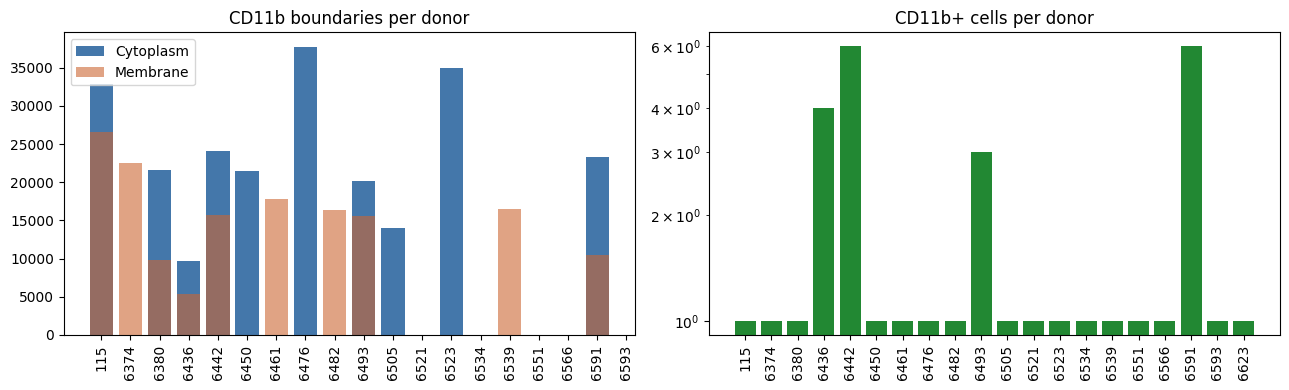

In [8]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].bar(per_donor.donor, per_donor.cyto_boundary, color='#4477AA', label='Cytoplasm')
ax[0].bar(per_donor.donor, per_donor.memb_boundary, color='#CC6633', alpha=.6, label='Membrane')
ax[0].set_title(f'{MARKER} boundaries per donor'); ax[0].legend(); ax[0].tick_params(axis='x', rotation=90)
ax[1].bar(per_donor.donor, per_donor.n_positive.clip(lower=1), color='#228833'); ax[1].set_yscale('log')
ax[1].set_title(f'{MARKER}+ cells per donor'); ax[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()


## 6 — Every marker with Cytoplasm and Membrane measurements, this donor


In [9]:
full  = pd.read_parquet(f)
marks = sorted({c.split('__',1)[1] for c in full.columns if c.startswith('Cytoplasm__')}
               & {c.split('__',1)[1] for c in full.columns if c.startswith('Membrane__')})
rows = []
for m in marks:
    a, b = full[f'Cytoplasm__{m}'].to_numpy(float), full[f'Membrane__{m}'].to_numpy(float)
    k = np.isfinite(a) & np.isfinite(b) & (a >= 0) & (b >= 0)
    a, b = a[k], b[k]
    t1, _ = find_boundary(a); t2, _ = find_boundary(b)
    n = int(((a > t1) & (b > t2)).sum())
    rows.append(dict(marker=m, n_cells=len(a), cyto_boundary=round(t1,1), memb_boundary=round(t2,1),
                     n_positive=n, pct=round(n/max(len(a),1)*100, 4)))
panel = pd.DataFrame(rows).sort_values('pct', ascending=False)
print(f'donor {DONOR}: {len(panel)} markers with both compartments')
panel


donor 6566: 12 markers with both compartments


,marker,n_cells,cyto_boundary,memb_boundary,n_positive,pct
11,Vimentin,1621163,1054.0,1104.5,510541,31.4923
10,Pan_Cytokeratin,1621163,1698.7,1468.1,306843,18.9273
2,CD163,1621163,2285.2,1520.0,11,0.0007
8,EpCAM,1621163,3455.9,3342.2,6,0.0004
6,CD68,1621163,3231.2,1849.7,3,0.0002
3,CD20,1621163,8997.4,6426.0,1,0.0001
0,B3TUBB,1621163,NaN,13711.7,0,0.0000
1,CD11b,1621163,NaN,NaN,0,0.0000
7,E_cadherin,1621163,NaN,NaN,0,0.0000
5,CD3e,1621163,741.5,NaN,0,0.0000
